## Artificial Neural Network (ANN) for Entrained Droplet Fraction
(GPU) — improved training


In [2]:
#imports
import os, math, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

#Reproducibility and Device setup
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True  # for reproducibility
torch.backends.cudnn.benchmark = False     # for reproducibility

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Configurations

DATA_PATH = r"../../data/entraineddropletfraction_VerticalFlow.csv"
# Feature names must match your DataFrame exactly:
feature_cols = ['D','Usg','UsL','rhol','rhog','st','MuL','Mug']
target_col   = 'e'  #entrained droplet fraction

#Model Training Hyperparameters
# Central place to control learning rate, batch size, hidden sizes, dropout, and others etc.


ACTIVATION     = "tanh"      # 'relu' | 'tanh' | 'sigmoid'  (paper used sigmoid)
HIDDEN_SIZES   = [32, 16]     # 8–16–8–1 by default; set to [6] for paper 8–6–1
DROPOUT_P      = 0.1         # 0.0 to disable
LR             = 1e-3        # lower LR than 0.01 for more stable training
WEIGHT_DECAY   = 1e-4        # small L2 regularization (set 0.0 to disable)
BATCH_SIZE     = 32
MAX_EPOCHS     = 5000
PATIENCE       = 200          # early stopping if val MSE doesn't improve
USE_LBFGS_POLISH = True    # do a short LBFGS polish at the end (optional)




In [4]:
# 2) Load & tidy data

df = pd.read_csv(DATA_PATH)
#Clean columns
df.columns = [c.strip().replace("σ","st").replace("roh","rho") for c in df.columns]
df = df.rename(columns={"e-":"e", "rhoL":"rhol"})  # keep 'rhol' per your column list

assert all(c in df.columns for c in feature_cols+[target_col]), "Missing expected columns."
#set the types
X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32).reshape(-1,1)

In [5]:
# Split 80/10/10, then scale inputs (no target scaling)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_val,   X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:  ", X_val.shape,   y_val.shape)
print("Test shape: ", X_test.shape,  y_test.shape)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

Xt = torch.tensor(X_train_s, dtype=torch.float32, device=device)
Xv = torch.tensor(X_val_s,   dtype=torch.float32, device=device)
Xw = torch.tensor(X_test_s,  dtype=torch.float32, device=device)

yt = torch.tensor(y_train, dtype=torch.float32, device=device)
yv = torch.tensor(y_val,   dtype=torch.float32, device=device)
yw = torch.tensor(y_test,  dtype=torch.float32, device=device)

Train shape: (1093, 8) (1093, 1)
Val shape:   (137, 8) (137, 1)
Test shape:  (137, 8) (137, 1)


In [6]:
# 4) Model

class MLP(nn.Module):
    def __init__(self, in_dim=8, hidden_sizes=[16,8], act="relu", dropout_p=0.0):
        super().__init__()
        acts = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid()
        }
        self.act = acts.get(act.lower(), nn.ReLU())
        self.do_drop = dropout_p > 0
        self.drop = nn.Dropout(p=dropout_p) if self.do_drop else nn.Identity()

        layers = []
        prev = in_dim
        for h in hidden_sizes:
            fc = nn.Linear(prev, h)
            nn.init.xavier_uniform_(fc.weight); nn.init.zeros_(fc.bias)
            layers += [fc, self.act, self.drop]
            prev = h
        out = nn.Linear(prev, 1)
        nn.init.xavier_uniform_(out.weight); nn.init.zeros_(out.bias)

        self.net = nn.Sequential(*layers, out)

    def forward(self, x):
        return self.net(x)

# To mirror the paper exactly (8–6–1 + Sigmoid), set:
# HIDDEN_SIZES = [6]; ACTIVATION = "sigmoid"; DROPOUT_P = 0.0

model = MLP(in_dim=8, hidden_sizes=HIDDEN_SIZES, act=ACTIVATION, dropout_p=DROPOUT_P).to(device)


In [7]:
#Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_ds = TensorDataset(Xt, yt)
val_ds   = TensorDataset(Xv, yv)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=256,        shuffle=False, drop_last=False)

best_val = float("inf")
best_state = None
fail_count = 0
train_losses, val_losses = [], []

In [8]:
#Train with early stopping

for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        yhat = model(xb)
        loss = criterion(yhat, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_mse = running / len(train_ds)

    # validation MSE
    model.eval()
    with torch.no_grad():
        v_sum = 0.0
        for xb, yb in val_loader:
            yhat = model(xb)
            v_sum += criterion(yhat, yb).item() * xb.size(0)
        val_mse = v_sum / len(val_ds)

    train_losses.append(train_mse)
    val_losses.append(val_mse)

    # early stopping
    if val_mse < best_val - 1e-9:
        best_val = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        fail_count = 0
    else:
        fail_count += 1

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE: {train_mse:.6f} | val MSE: {val_mse:.6f} | best: {best_val:.6f} | fails: {fail_count}")

    if fail_count >= PATIENCE:
        print(f"Early stop at epoch {epoch} (no val improvement for {PATIENCE} checks).")
        break
# restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

Epoch    1 | train MSE: 0.272809 | val MSE: 0.083984 | best: 0.083984 | fails: 0
Epoch  100 | train MSE: 0.044739 | val MSE: 0.041892 | best: 0.041777 | fails: 8
Epoch  200 | train MSE: 0.039286 | val MSE: 0.036374 | best: 0.035413 | fails: 9
Epoch  300 | train MSE: 0.037375 | val MSE: 0.032851 | best: 0.032501 | fails: 5
Epoch  400 | train MSE: 0.035998 | val MSE: 0.030948 | best: 0.029710 | fails: 10
Epoch  500 | train MSE: 0.034203 | val MSE: 0.029599 | best: 0.027933 | fails: 1
Epoch  600 | train MSE: 0.034614 | val MSE: 0.029433 | best: 0.026540 | fails: 11
Epoch  700 | train MSE: 0.031702 | val MSE: 0.026583 | best: 0.025653 | fails: 8
Epoch  800 | train MSE: 0.032709 | val MSE: 0.025475 | best: 0.024403 | fails: 33
Epoch  900 | train MSE: 0.030062 | val MSE: 0.023695 | best: 0.023673 | fails: 42
Epoch 1000 | train MSE: 0.031053 | val MSE: 0.023314 | best: 0.022859 | fails: 11
Epoch 1100 | train MSE: 0.030252 | val MSE: 0.022747 | best: 0.022114 | fails: 5
Epoch 1200 | train MSE:

In [9]:
#Optional LBFGS polish (full-batch)

#LBFGS polish

if USE_LBFGS_POLISH:
    print("Starting LBFGS polish...")
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=50, history_size=10)

    def closure():
        lbfgs.zero_grad()
        yhat = model(Xt)
        loss = criterion(yhat, yt)
        loss.backward()
        return loss

    best_val_lbfgs = float("inf")
    best_state_lbfgs = None
    for _ in range(10):  # a few outer steps
        loss = lbfgs.step(closure)
        with torch.no_grad():
            v = criterion(model(Xv), yv).item()
        if v < best_val_lbfgs:
            best_val_lbfgs = v
            best_state_lbfgs = {k: v_.detach().cpu().clone() for k, v_ in model.state_dict().items()}
    if best_state_lbfgs is not None and best_val_lbfgs < best_val:
        print(f"LBFGS improved val MSE: {best_val:.6f} -> {best_val_lbfgs:.6f}")
        model.load_state_dict(best_state_lbfgs)

Starting LBFGS polish...
LBFGS improved val MSE: 0.014047 -> 0.004263


In [10]:
# 8) Evaluate splits

def eval_split(Xt_, yt_):
    model.eval()
    with torch.no_grad():
        pred = model(Xt_).cpu().numpy().ravel()
    true = yt_.cpu().numpy().ravel()
    mse  = mean_squared_error(true, pred)
    rmse = math.sqrt(mse)
    r2   = r2_score(true, pred)
    return pred, {"MSE": mse, "RMSE": rmse, "R2": r2}

pred_train, metr_train = eval_split(Xt, yt)
pred_val,   metr_val   = eval_split(Xv, yv)
pred_test,  metr_test  = eval_split(Xw, yw)

print("\n Performance of ANN with feature engineering and LBFGS polish")
print("ACTIVATION tanh, HIDDEN_SIZES   = [32, 16], weight decay = 1e-4")
print("Train:", metr_train)
print("Val:  ", metr_val)
print("Test: ", metr_test)


 Performance of ANN with feature engineering and LBFGS polish
ACTIVATION tanh, HIDDEN_SIZES   = [32, 16], weight decay = 1e-4
Train: {'MSE': 0.0043198177590966225, 'RMSE': 0.06572532053247532, 'R2': 0.9485968947410583}
Val:   {'MSE': 0.00426335446536541, 'RMSE': 0.06529436779206466, 'R2': 0.9492157101631165}
Test:  {'MSE': 0.00729031627997756, 'RMSE': 0.08538334896206379, 'R2': 0.9039082527160645}


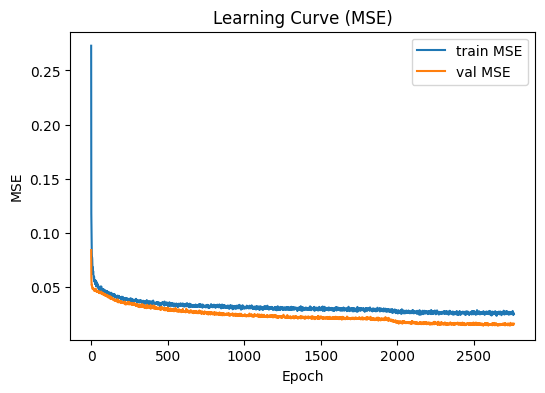

In [11]:
# 9) Learning curve

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="train MSE")
plt.plot(val_losses,   label="val MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Learning Curve (MSE)"); plt.legend()
plt.show()

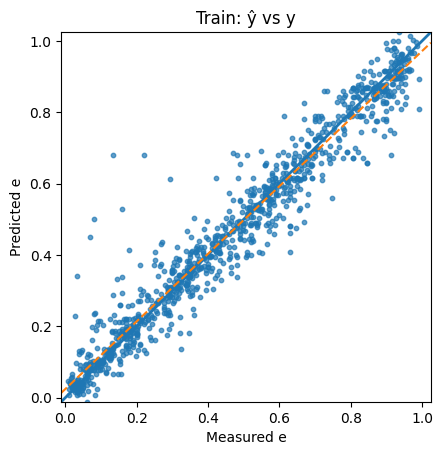

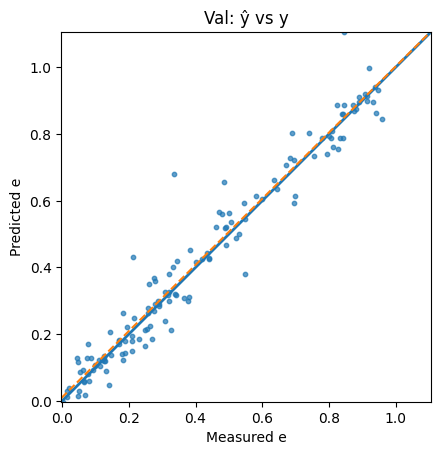

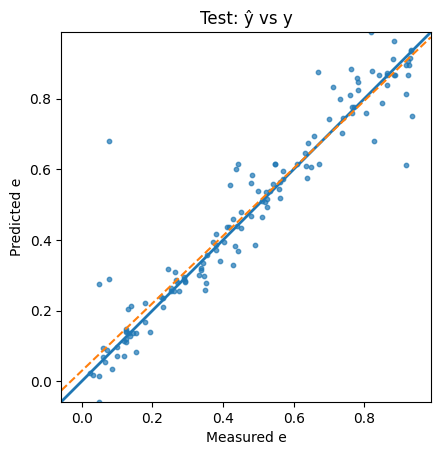

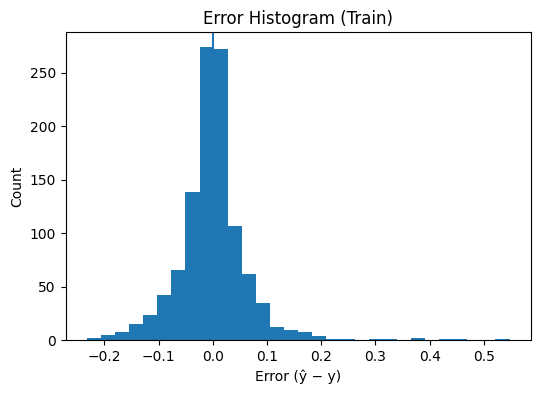

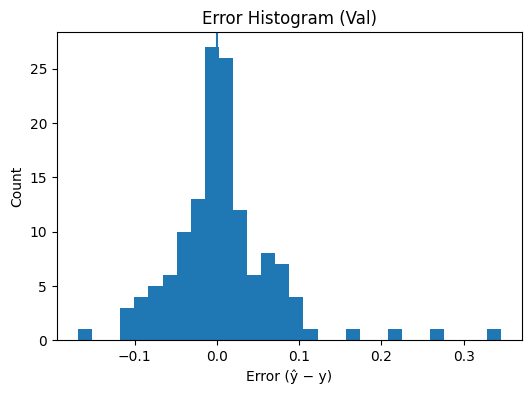

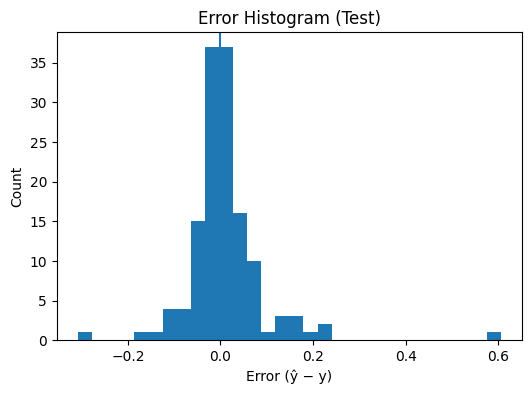

In [12]:
def reg_plot(y_true, y_pred, title):
    import numpy as np
    import matplotlib.pyplot as plt

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    plt.figure(figsize=(4.8, 4.8))
    plt.scatter(y_true, y_pred, s=10, alpha=0.7)
    mn = min(y_true.min(), y_pred.min()); mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], lw=2)  # 45° line
    # Optional: least-squares fit line (calibration)
    m, b = np.polyfit(y_true, y_pred, 1)
    plt.plot([mn, mx], [m*mn + b, m*mx + b], linestyle="--")
    plt.xlabel("Measured e"); plt.ylabel("Predicted e"); plt.title(title)
    plt.xlim(mn, mx); plt.ylim(mn, mx); plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

reg_plot(yt.cpu().numpy().ravel(), pred_train, "Train: ŷ vs y")
reg_plot(yv.cpu().numpy().ravel(), pred_val,   "Val: ŷ vs y")
reg_plot(yw.cpu().numpy().ravel(), pred_test,  "Test: ŷ vs y")

def err_hist(y_true, y_pred, title):
    import numpy as np
    import matplotlib.pyplot as plt
    err = np.asarray(y_pred).ravel() - np.asarray(y_true).ravel()
    plt.figure(figsize=(6,4))
    plt.hist(err, bins=30)
    plt.axvline(0.0)  # zero-error reference
    plt.title(title); plt.xlabel("Error (ŷ − y)"); plt.ylabel("Count")
    plt.show()
    return err

e_train = err_hist(yt.cpu().numpy().ravel(), pred_train, "Error Histogram (Train)")
e_val   = err_hist(yv.cpu().numpy().ravel(), pred_val,   "Error Histogram (Val)")
e_test  = err_hist(yw.cpu().numpy().ravel(), pred_test,  "Error Histogram (Test)")


In [ ]:
#Train with early stopping

for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        yhat = model(xb)
        loss = criterion(yhat, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_mse = running / len(train_ds)

    # validation MSE
    model.eval()
    with torch.no_grad():
        v_sum = 0.0
        for xb, yb in val_loader:
            yhat = model(xb)
            v_sum += criterion(yhat, yb).item() * xb.size(0)
        val_mse = v_sum / len(val_ds)

    train_losses.append(train_mse)
    val_losses.append(val_mse)

    # early stopping
    if val_mse < best_val - 1e-9:
        best_val = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        fail_count = 0
    else:
        fail_count += 1

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE: {train_mse:.6f} | val MSE: {val_mse:.6f} | best: {best_val:.6f} | fails: {fail_count}")

    if fail_count >= PATIENCE:
        print(f"Early stop at epoch {epoch} (no val improvement for {PATIENCE} checks).")
        break
# restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

Epoch    1 | train MSE: 0.272809 | val MSE: 0.083984 | best: 0.083984 | fails: 0
Epoch  100 | train MSE: 0.044739 | val MSE: 0.041892 | best: 0.041777 | fails: 8
Epoch  200 | train MSE: 0.039286 | val MSE: 0.036374 | best: 0.035413 | fails: 9
Epoch  300 | train MSE: 0.037375 | val MSE: 0.032851 | best: 0.032501 | fails: 5
Epoch  400 | train MSE: 0.035998 | val MSE: 0.030948 | best: 0.029710 | fails: 10
Epoch  500 | train MSE: 0.034203 | val MSE: 0.029599 | best: 0.027933 | fails: 1
Epoch  600 | train MSE: 0.034614 | val MSE: 0.029433 | best: 0.026540 | fails: 11
Epoch  700 | train MSE: 0.031702 | val MSE: 0.026583 | best: 0.025653 | fails: 8
Epoch  800 | train MSE: 0.032709 | val MSE: 0.025475 | best: 0.024403 | fails: 33
Epoch  900 | train MSE: 0.030062 | val MSE: 0.023695 | best: 0.023673 | fails: 42
Epoch 1000 | train MSE: 0.031053 | val MSE: 0.023314 | best: 0.022859 | fails: 11
Epoch 1100 | train MSE: 0.030252 | val MSE: 0.022747 | best: 0.022114 | fails: 5
Epoch 1200 | train MSE:

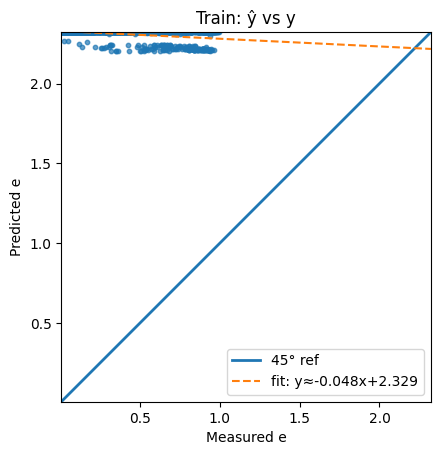

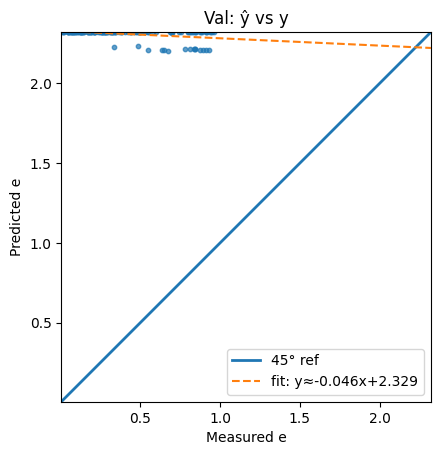

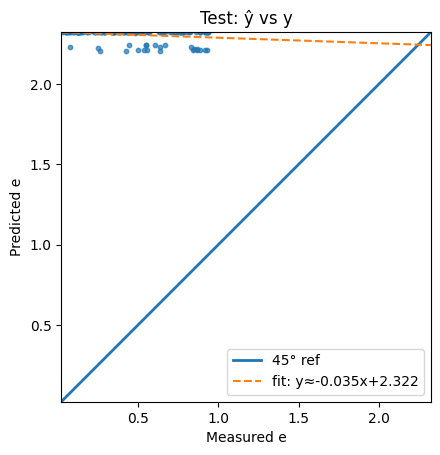

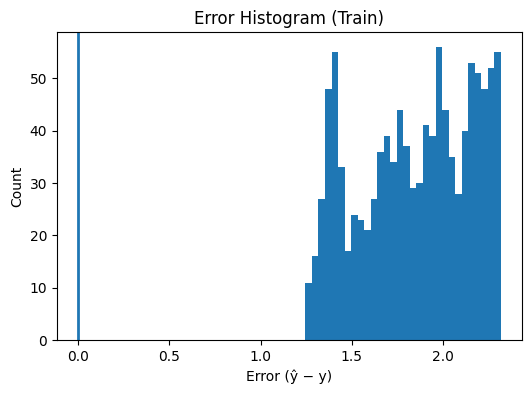

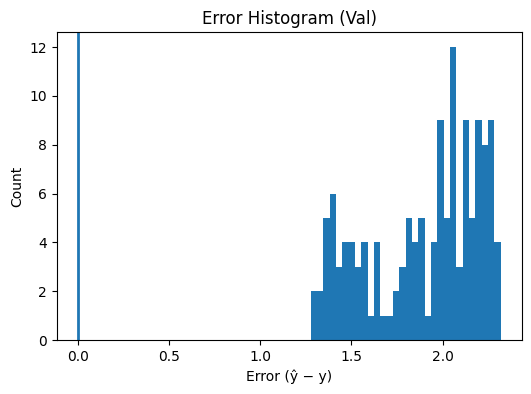

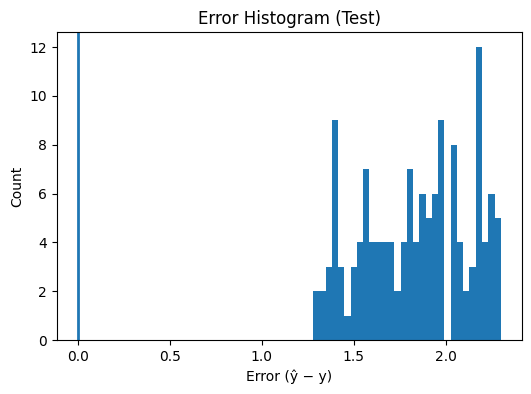

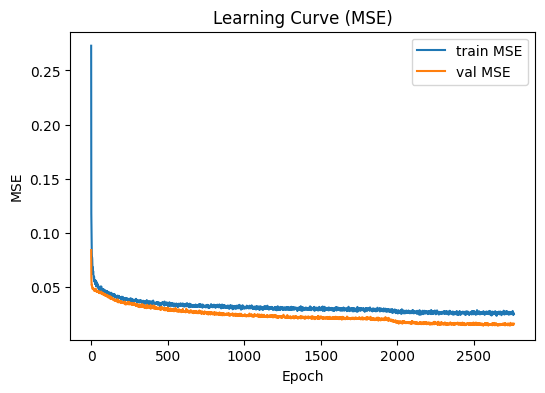

  0%|          | 0/137 [00:00<?, ?it/s]

ipykernel_19124\1023688602.py:124: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar")


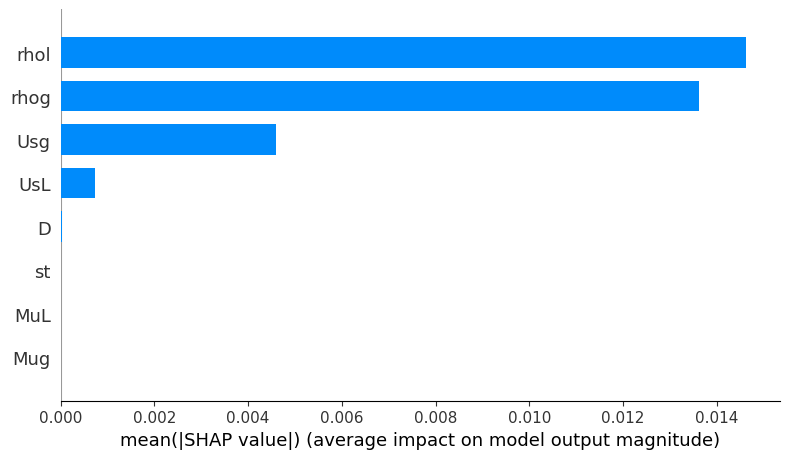

ipykernel_19124\1023688602.py:126: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names)


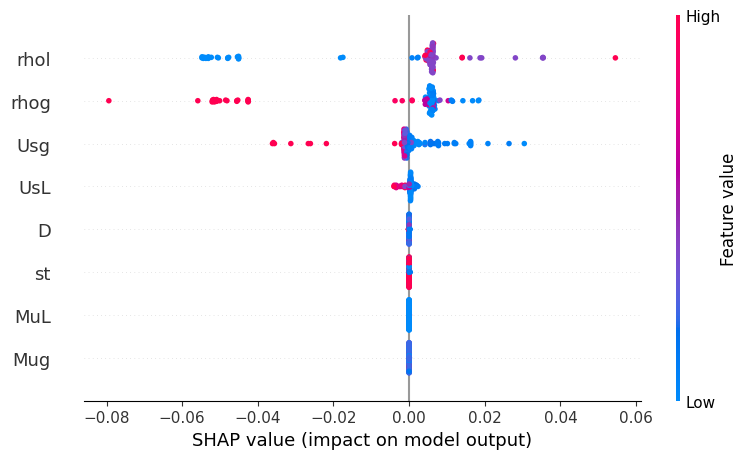

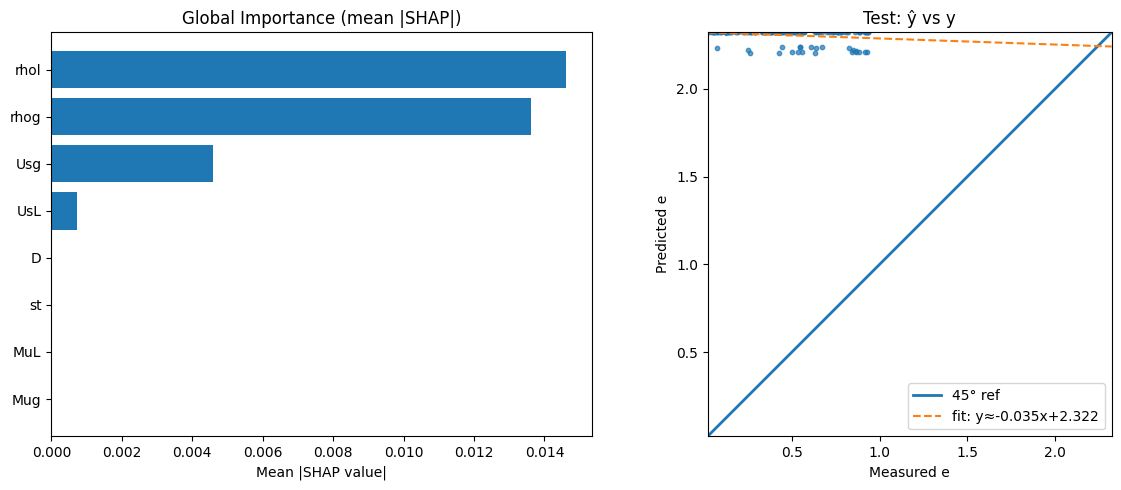

Top features by mean |SHAP|:
          rhol: 0.014617
          rhog: 0.013613
           Usg: 0.004599
           UsL: 0.000731
             D: 0.000022
            st: 0.000016
           MuL: 0.000001
           Mug: 0.000001


In [13]:
# ===== SHAP (KernelExplainer) + Residual Diagnostics =====
# Requirements: shap, numpy, matplotlib, torch

import numpy as np
import torch
import shap
import matplotlib.pyplot as plt

# -------------------------
# 0) Pre-reqs / assumptions
# -------------------------
# Assumes you already have:
# model: trained torch.nn.Module
# device: torch.device (e.g., torch.device('cuda') or 'cpu')
# X_train, X_val, X_test: numpy arrays (SCALED features, same order as training)
# y_train, y_val, y_test: numpy arrays with shape (n, 1) or (n,)
# feature_cols: list[str] with exact model input order
# train_losses, val_losses: optional lists of MSE per epoch (for learning curve)
model.eval()

# ----------------------------------------
# 1) Residuals and predictions (torch->np)
# ----------------------------------------
def predict_numpy(X_np, batch_size=2048):
    """Predict helper that batches numpy -> torch -> numpy for speed and stability."""
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            yb = model(xb).squeeze(-1).detach().cpu().numpy()
            preds.append(yb)
    return np.concatenate(preds, axis=0)

yhat_train = predict_numpy(X_train)
yhat_val   = predict_numpy(X_val)
yhat_test  = predict_numpy(X_test)

# Ensure targets are 1D
y_train_1d = y_train.reshape(-1)
y_val_1d   = y_val.reshape(-1)
y_test_1d  = y_test.reshape(-1)

# ------------------------------
# 2) Residual diagnostics plots
# ------------------------------
def reg_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    plt.figure(figsize=(4.8, 4.8))
    plt.scatter(y_true, y_pred, s=10, alpha=0.7)
    mn = min(y_true.min(), y_pred.min()); mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], lw=2, label="45° ref")
    # calibration line
    m, b = np.polyfit(y_true, y_pred, 1)
    plt.plot([mn, mx], [m*mn + b, m*mx + b], linestyle="--", label=f"fit: y≈{m:.3f}x+{b:.3f}")
    plt.xlabel("Measured e")
    plt.ylabel("Predicted e")
    plt.title(title)
    plt.xlim(mn, mx); plt.ylim(mn, mx)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.show()

def err_hist(y_true, y_pred, title):
    err = np.asarray(y_pred).ravel() - np.asarray(y_true).ravel()
    plt.figure(figsize=(6, 4))
    plt.hist(err, bins=30)
    plt.axvline(0.0, lw=2)
    plt.title(title)
    plt.xlabel("Error (ŷ − y)")
    plt.ylabel("Count")
    plt.show()
    return err

# Scatter and histograms (Train/Val/Test)
reg_plot(y_train_1d, yhat_train, "Train: ŷ vs y")
reg_plot(y_val_1d,   yhat_val,   "Val: ŷ vs y")
reg_plot(y_test_1d,  yhat_test,  "Test: ŷ vs y")

e_train = err_hist(y_train_1d, yhat_train, "Error Histogram (Train)")
e_val   = err_hist(y_val_1d,   yhat_val,   "Error Histogram (Val)")
e_test  = err_hist(y_test_1d,  yhat_test,  "Error Histogram (Test)")

# (Optional) Learning curve if you tracked losses during training
try:
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label="train MSE")
    plt.plot(val_losses,   label="val MSE")
    plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Learning Curve (MSE)"); plt.legend()
    plt.show()
except NameError:
    pass

# -------------------------------------------------------
# 3) SHAP KernelExplainer (robust, model-agnostic)
# -------------------------------------------------------
# Keep background small (50–200) and representative to speed up SHAP
rng = np.random.default_rng(42)
bg_size = min(100, len(X_train))
bg_idx  = rng.choice(len(X_train), size=bg_size, replace=False)
background = X_train[bg_idx]

# Predict function that SHAP will call (MUST take np array, return np array)
def predict_fn(x_np):
    return predict_numpy(np.asarray(x_np))

# Build explainer
explainer = shap.KernelExplainer(predict_fn, background)

# Explain a modest slice of test set for speed
sample_size = min(200, len(X_test))
sample_idx  = rng.choice(len(X_test), size=sample_size, replace=False)
X_sample    = X_test[sample_idx]

# Compute SHAP values
# nsamples="auto" is fine; for faster runs use a smaller integer (e.g., nsamples=100)
shap_values = explainer.shap_values(X_sample, nsamples="auto")

# -------------------------------------------------------
# 4) SHAP Plots (summary bar + beeswarm)
# -------------------------------------------------------
feature_names = list(feature_cols)  # ensure list (not Index)
# Global feature importance (mean |SHAP|):
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar")
# Distribution of impacts per feature:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)

# -------------------------------------------------------
# 5) (Optional) Side-by-side: SHAP bar + Test residual scatter
# -------------------------------------------------------
# Creates a single figure you can screenshot for your report.
import matplotlib.gridspec as gridspec

# Compute a simple importance ranking to print alongside
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
rank = np.argsort(mean_abs_shap)[::-1]
ranked_feats = [(feature_names[i], mean_abs_shap[i]) for i in rank]

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Left: SHAP bar (top-10)
ax1 = fig.add_subplot(gs[0])
top_k = min(10, len(feature_names))
top_idx = rank[:top_k]
ax1.barh([feature_names[i] for i in top_idx][::-1],
         mean_abs_shap[top_idx][::-1])
ax1.set_title("Global Importance (mean |SHAP|)")
ax1.set_xlabel("Mean |SHAP value|")

# Right: Residual scatter (Test)
ax2 = fig.add_subplot(gs[1])
ax2.scatter(y_test_1d, yhat_test, s=10, alpha=0.7)
mn = min(y_test_1d.min(), yhat_test.min()); mx = max(y_test_1d.max(), yhat_test.max())
ax2.plot([mn, mx], [mn, mx], lw=2, label="45° ref")
m, b = np.polyfit(y_test_1d, yhat_test, 1)
ax2.plot([mn, mx], [m*mn + b, m*mx + b], linestyle="--", label=f"fit: y≈{m:.3f}x+{b:.3f}")
ax2.set_xlim(mn, mx); ax2.set_ylim(mn, mx)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlabel("Measured e"); ax2.set_ylabel("Predicted e")
ax2.set_title("Test: ŷ vs y")
ax2.legend()

plt.tight_layout()
plt.show()

# Print quick ranked list (useful for logs)
print("Top features by mean |SHAP|:")
for name, val in ranked_feats[:10]:
    print(f"  {name:>12s}: {val:.6f}")
